# E-Commerce Sales Analysis Dashboard

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

In [3]:
df = pd.read_csv("/home/jawad/Downloads/ecommerce_sales_dataset_5000.csv")
df

,Order_ID,Date,Customer_ID,Age,Gender,City,Product,Category,Quantity,Price,Discount,Total_Amount,Payment_Method,Rating,Returned
0,100001,2025-05-06,1228,26,Male,Buner,Chair,Furniture,1,779,10,701.10,Cash,5,No
1,100002,2025-09-16,1616,19,Male,Buner,Laptop,Electronics,1,243,5,230.85,Card,2,No
2,100003,2025-12-24,1432,39,Female,Islamabad,Desk,Furniture,1,797,5,757.15,Cash,3,Yes
3,100004,2025-11-06,1270,20,Female,Buner,Phone,Electronics,1,387,10,348.30,Cash,4,Yes
4,100005,2025-10-23,1196,63,Male,Peshawar,Desk,Furniture,5,926,10,4167.00,Online,2,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,104996,2025-08-05,1919,39,Female,Buner,Sofa,Furniture,1,450,10,405.00,Cash,5,No
4996,104997,2025-09-07,1713,35,Male,Islamabad,Sofa,Furniture,3,635,20,1524.00,Cash,2,Yes
4997,104998,2025-09-14,1482,19,Male,Karachi,Phone,Electronics,5,899,15,3820.75,Card,3,No
4998,104999,2025-12-28,1710,42,Female,Islamabad,Desk,Furniture,3,355,15,905.25,Cash,5,Yes


In [4]:
print("Data set ist 5 rows :",df.head())
print("\n")
print("information about the data set : ",df.info())
print("\n")
print("description of the data sets :\n",df.describe())


Data set ist 5 rows :    Order_ID        Date  Customer_ID  Age  Gender       City Product  \
0    100001  2025-05-06         1228   26    Male      Buner   Chair   
1    100002  2025-09-16         1616   19    Male      Buner  Laptop   
2    100003  2025-12-24         1432   39  Female  Islamabad    Desk   
3    100004  2025-11-06         1270   20  Female      Buner   Phone   
4    100005  2025-10-23         1196   63    Male   Peshawar    Desk   

      Category  Quantity  Price  Discount  Total_Amount Payment_Method  \
0    Furniture         1    779        10        701.10           Cash   
1  Electronics         1    243         5        230.85           Card   
2    Furniture         1    797         5        757.15           Cash   
3  Electronics         1    387        10        348.30           Cash   
4    Furniture         5    926        10       4167.00         Online   

   Rating Returned  
0       5       No  
1       2       No  
2       3      Yes  
3       4      Y

# Data Cleaning

In [5]:
# removing duplicate data
duplicate_count = df.duplicated().sum()
print("number of duplcated rows : ", duplicate_count)
print('\n')
duplicate = df.drop_duplicates()
print("Duplicates rows : ",duplicate)



#handle missing values
print('\n')
print(df.isnull().sum())
missing = df.isnull().sum()
print(missing[missing > 0])
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Price"] = df["Price"].fillna(df["Price"].mean())
df["Total_Amount"]= df["Total_Amount"].fillna(df["Total_Amount"].mode())

print("\n\n")

# fix data types
print("Data types of the data : ",df.dtypes)
df["Price"] = df["Price"].astype(float)
df["Rating"]= df["Rating"].astype(int)
df["Date"] = pd.to_datetime(df["Date"])

print("\n\n")

# removing outlier
outlier = []
Q1 = np.quantile(df["Total_Amount"],0.25)
Q3 =  np.quantile(df["Total_Amount"],0.75)
IQR = Q3 - Q1
print("inter quartile range : ",IQR)
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)
for i in df["Total_Amount"]:
    if (i < lower_bound )| (i > upper_bound):
        outlier.append(i)
print("outlier  : ",outlier)




number of duplcated rows :  0


Duplicates rows :        Order_ID        Date  Customer_ID  Age  Gender       City Product  \
0       100001  2025-05-06         1228   26    Male      Buner   Chair   
1       100002  2025-09-16         1616   19    Male      Buner  Laptop   
2       100003  2025-12-24         1432   39  Female  Islamabad    Desk   
3       100004  2025-11-06         1270   20  Female      Buner   Phone   
4       100005  2025-10-23         1196   63    Male   Peshawar    Desk   
...        ...         ...          ...  ...     ...        ...     ...   
4995    104996  2025-08-05         1919   39  Female      Buner    Sofa   
4996    104997  2025-09-07         1713   35    Male  Islamabad    Sofa   
4997    104998  2025-09-14         1482   19    Male    Karachi   Phone   
4998    104999  2025-12-28         1710   42  Female  Islamabad    Desk   
4999    105000  2025-01-10         1932   50    Male  Islamabad  Jacket   

         Category  Quantity  Price  Discount  To

# EDA

In [6]:
# total sales
total_sale = df["Total_Amount"].sum()
print("total sale : ",total_sale)
# total orders
total_order = len(df)
print("total orders : ", total_order)
# Average Order Value
average_order_value = df["Total_Amount"].mean()
print("Average Order Value:", round(average_order_value, 2))
print("\n")
# highest selling category
category_sale = df.groupby("Category")["Quantity"].sum()
highest_selling_category = category_sale.idxmax()
print("highest_selling_category",highest_selling_category)
# highest Revenue Category 
revenue_category = df.groupby("Category")["Total_Amount"].sum()
highest_Revenue = revenue_category.idxmax()
print("highest_Revenue",highest_Revenue)
# monthly sale
monthly_sale = df.groupby(df["Date"].dt.month)["Total_Amount"].sum()
print("\nmonthly sale : ", monthly_sale)
# daily sales
daily_sale = df.groupby(df["Date"].dt.day)["Total_Amount"].sum()
print("\nDaily sales : \n",daily_sale)

total sale :  6822807.75
total orders :  5000
Average Order Value: 1364.56


highest_selling_category Clothing
highest_Revenue Clothing

monthly sale :  Date
1     531062.20
2     528324.70
3     536385.85
4     520329.45
5     616879.75
6     570354.70
7     537389.00
8     644771.50
9     593025.85
10    579371.15
11    559656.95
12    605256.65
Name: Total_Amount, dtype: float64

Daily sales : 
 Date
1     202148.65
2     275277.30
3     224940.10
4     202816.00
5     236222.85
6     204504.25
7     224180.15
8     242425.70
9     213062.20
10    229869.90
11    218777.95
12    225070.35
13    201732.60
14    236588.15
15    239727.95
16    211007.95
17    215909.50
18    198354.55
19    258039.90
20    223386.20
21    233104.85
22    206927.55
23    228876.90
24    245093.70
25    255269.60
26    237054.35
27    199123.10
28    223233.65
29    203623.15
30    158474.40
31    147984.30
Name: Total_Amount, dtype: float64


In [7]:
# City-wise Revenue
city_wise_rev = df.groupby("City")["Total_Amount"].sum()
print("city wise revenue : \n", city_wise_rev)
print("\n")
# Gender-wise Sales
gender_wise_rev = df.groupby("Gender")["Total_Amount"].sum()
print("gender wise revenue : \n", gender_wise_rev)
print("\n")
# Payment Method Distribution
payment_distrbution  = df["Payment_Method"].value_counts()
print("payment distribution : ", payment_distrbution)
# converting to percentage 
payment_distrbution_per = df["Payment_Method"].value_counts(normalize=True)*100
print("payment distribution percentage : ", payment_distrbution_per)
# return rate 
return_order = (df["Returned"]=="Yes").sum()
total_order = len(df)
return_rate = return_order/total_order * 100
print("return rate : ",return_rate)
# Average Customer Rating
average_rating = df["Rating"].mean()
print(f"Average Customer Rating: {average_rating:.2f}")

city wise revenue : 
 City
Buner        1316318.75
Islamabad    1480199.40
Karachi      1345674.75
Lahore       1356732.35
Peshawar     1323882.50
Name: Total_Amount, dtype: float64


gender wise revenue : 
 Gender
Female    3485040.80
Male      3337766.95
Name: Total_Amount, dtype: float64


payment distribution :  Payment_Method
Card      1700
Online    1671
Cash      1629
Name: count, dtype: int64
payment distribution percentage :  Payment_Method
Card      34.00
Online    33.42
Cash      32.58
Name: proportion, dtype: float64
return rate :  49.78
Average Customer Rating: 3.01


In [8]:
# mean 
price_mean = df["Price"].mean()
print("average price : ",price_mean)
total_amount_mean = df["Total_Amount"].mean()
print("total amount average : ",total_amount_mean)
mean_rat = df["Rating"].mean()
print("Average Rating : ", mean_rat)
# mode 
mode_rating = df["Rating"].mode()
print("frequentlu occuring rating : ", mode_rating)
payment_method = df["Payment_Method"].mode()
print("payment method frequently occuring : ",payment_method)
# Calculation of varience manually 
mean = df["Total_Amount"].mean()
deviation = df["Total_Amount"] - mean
square_deviaton = deviation ** 2
sum_of_squared_devia = square_deviaton.sum()
n= len(df)
varienc = sum_of_squared_devia / (n-1)
print("mean : ",mean)
print("Sample varience : ", varienc.round(3))
print("\n\n")
# standard deviation
std = df.select_dtypes(include="number").std()
print("Standard deviation : \n", std)

average price :  505.7432
total amount average :  1364.56155
Average Rating :  3.006
frequentlu occuring rating :  0    4
Name: Rating, dtype: int64
payment method frequently occuring :  0    Card
Name: Payment_Method, dtype: str
mean :  1364.56155
Sample varience :  1148686.956



Standard deviation : 
 Order_ID        1443.520003
Customer_ID      288.436794
Age               13.981634
Quantity           1.412864
Price            281.737070
Discount           7.081295
Total_Amount    1071.768145
Rating             1.399127
dtype: float64


In [9]:

# Quartiles
Quartiles = df.select_dtypes(include="number").quantile([0.25,0.50,0.75])
print("Quartiles : \n", Quartiles)
# Percentiles 
Percentiles = df.select_dtypes(include="number").quantile([0.10,0.25,0.50,0.75])
print("\n\n percentiles : ",Percentiles)


Quartiles : 
        Order_ID  Customer_ID   Age  Quantity   Price  Discount  Total_Amount  \
0.25  101250.75       1252.0  29.0       2.0  261.75       5.0       511.925   
0.50  102500.50       1502.0  42.0       3.0  506.00      10.0      1051.650   
0.75  103750.25       1746.0  54.0       4.0  745.00      15.0      2009.600   

      Rating  
0.25     2.0  
0.50     3.0  
0.75     4.0  


 percentiles :         Order_ID  Customer_ID   Age  Quantity   Price  Discount  Total_Amount  \
0.10  100500.90       1101.9  22.0       1.0  115.00       0.0       223.180   
0.25  101250.75       1252.0  29.0       2.0  261.75       5.0       511.925   
0.50  102500.50       1502.0  42.0       3.0  506.00      10.0      1051.650   
0.75  103750.25       1746.0  54.0       4.0  745.00      15.0      2009.600   

      Rating  
0.10     1.0  
0.25     2.0  
0.50     3.0  
0.75     4.0  


In [10]:
df

,Order_ID,Date,Customer_ID,Age,Gender,City,Product,Category,Quantity,Price,Discount,Total_Amount,Payment_Method,Rating,Returned
0,100001,2025-05-06,1228,26,Male,Buner,Chair,Furniture,1,779.0,10,701.10,Cash,5,No
1,100002,2025-09-16,1616,19,Male,Buner,Laptop,Electronics,1,243.0,5,230.85,Card,2,No
2,100003,2025-12-24,1432,39,Female,Islamabad,Desk,Furniture,1,797.0,5,757.15,Cash,3,Yes
3,100004,2025-11-06,1270,20,Female,Buner,Phone,Electronics,1,387.0,10,348.30,Cash,4,Yes
4,100005,2025-10-23,1196,63,Male,Peshawar,Desk,Furniture,5,926.0,10,4167.00,Online,2,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,104996,2025-08-05,1919,39,Female,Buner,Sofa,Furniture,1,450.0,10,405.00,Cash,5,No
4996,104997,2025-09-07,1713,35,Male,Islamabad,Sofa,Furniture,3,635.0,20,1524.00,Cash,2,Yes
4997,104998,2025-09-14,1482,19,Male,Karachi,Phone,Electronics,5,899.0,15,3820.75,Card,3,No
4998,104999,2025-12-28,1710,42,Female,Islamabad,Desk,Furniture,3,355.0,15,905.25,Cash,5,Yes


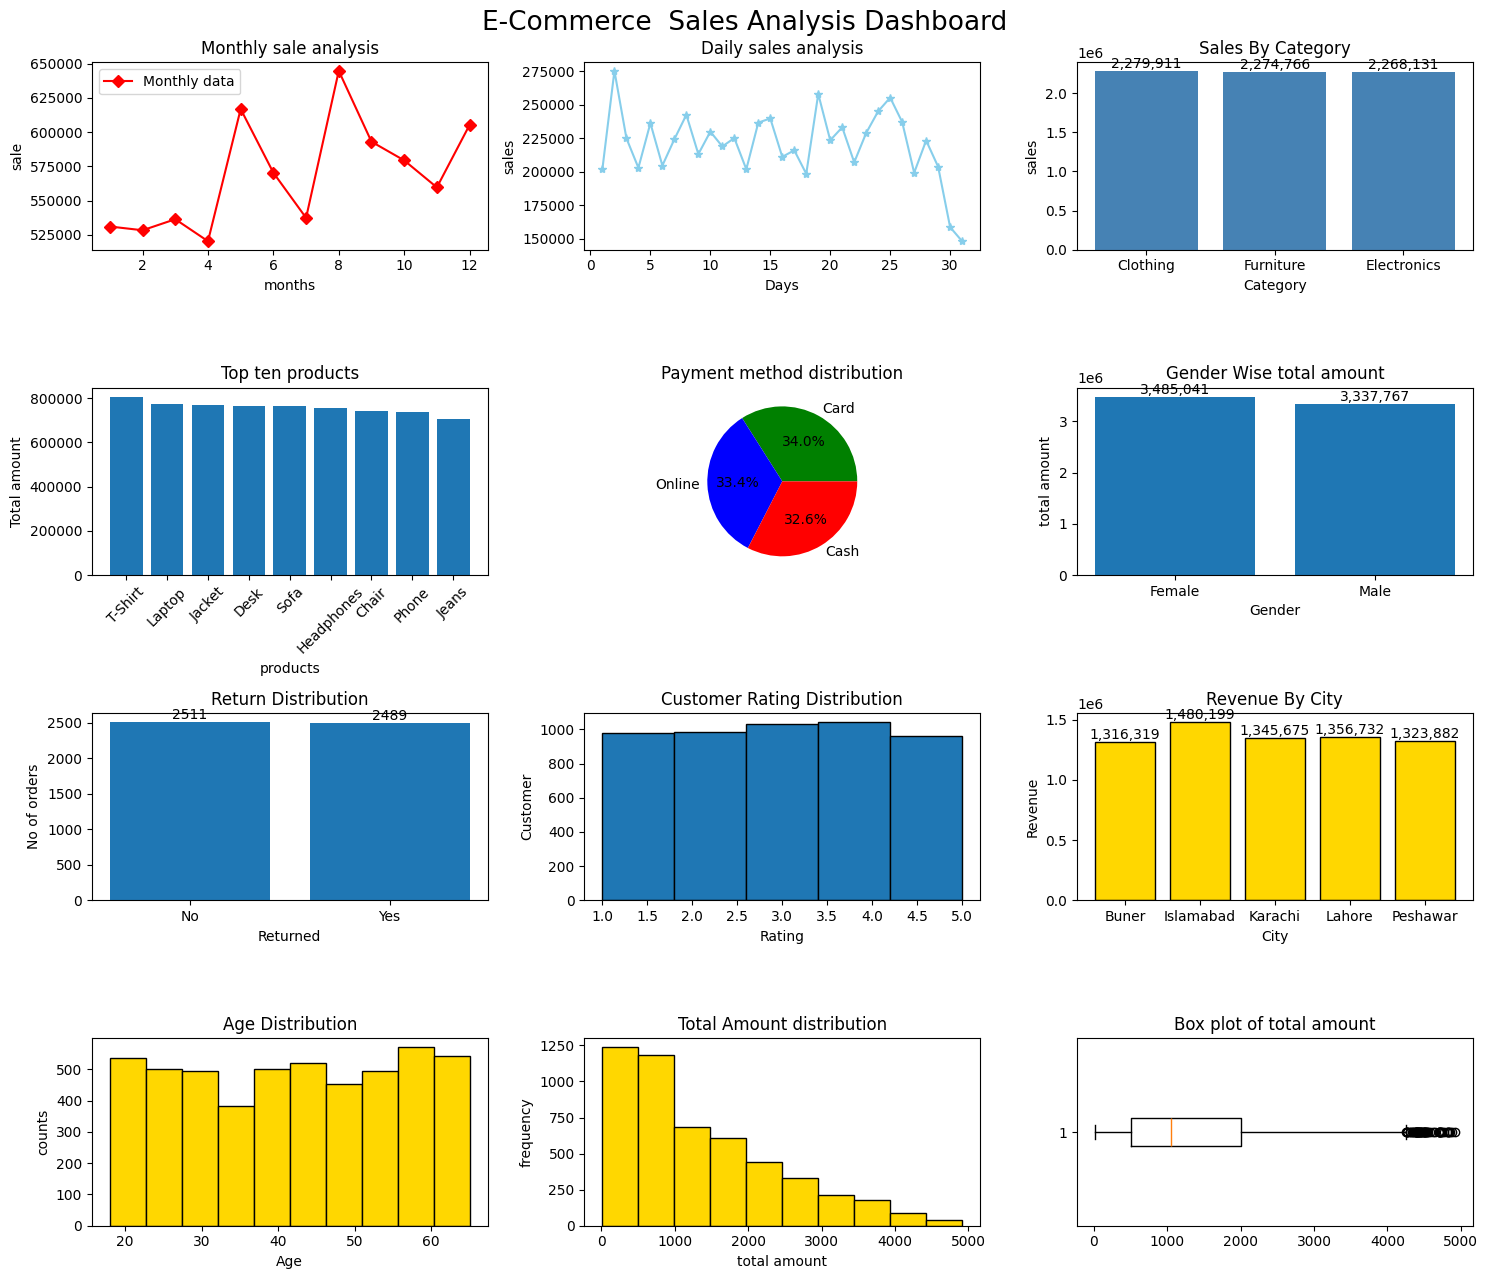

In [86]:
# dashboard
fig,ax = plt.subplots(4,3,figsize=(15,13))
# subplot one 
# monthly sales analysi
monthly_sale = df.groupby(df["Date"].dt.month)["Total_Amount"].sum()
ax[0,0].plot(monthly_sale,marker="D",label="Monthly data",color="red")
ax[0,0].set_title("Monthly sale analysis")
ax[0,0].set_xlabel("months")
ax[0,0].set_ylabel("sale")
ax[0,0].legend()


# subplot two
# Daily sale analysis
daily_sale = df.groupby(df["Date"].dt.day)["Total_Amount"].sum()
ax[0,1].plot(daily_sale,color="skyblue",marker="*",label="daily_sale")
ax[0,1].set_title("Daily sales analysis")
ax[0,1].set_xlabel("Days")
ax[0,1].set_ylabel("sales")



# subplot three
# sales by category
sales_by_category = df.groupby("Category")["Total_Amount"].sum().sort_values(ascending=False)
bar = ax[0,2].bar(sales_by_category.index,sales_by_category.values,color="steelblue")
ax[0,2].bar_label(bar , fmt='{:,.0f}')
ax[0,2].set_title("Sales By Category")
ax[0,2].set_xlabel("Category")
ax[0,2].set_ylabel("sales")

# subplot four 
# top ten products
top_ten_products = df.groupby("Product")["Total_Amount"].sum().sort_values(ascending=False).head(10)
ax[1,0].bar(top_ten_products.index,top_ten_products.values)
ax[1,0].set_title("Top ten products")
ax[1,0].set_xlabel("products")
ax[1,0].set_ylabel("Total amount")
ax[1,0].tick_params(axis='x', rotation=45)


# subplot five
# payment method distribution
payment_method = df["Payment_Method"].value_counts()
ax[1,1].pie(payment_method.values,labels=payment_method.index,autopct="%1.1f%%",colors=["green","blue","red"])
ax[1,1].set_title("Payment method distribution")


# subplot six
# gender wise revenue
gender_wise = df.groupby("Gender")["Total_Amount"].sum()
bar = ax[1,2].bar(gender_wise.index,gender_wise.values)
ax[1,2].bar_label(bar,fmt='{:,.0f}')
ax[1,2].set_title("Gender Wise total amount")
ax[1,2].set_xlabel("Gender")
ax[1,2].set_ylabel("total amount")


# subplot seven
##  return distribution bar chart
return_dis = df["Returned"].value_counts()
bar = ax[2,0].bar(return_dis.index,return_dis.values)
ax[2,0].bar_label(bar)
ax[2,0].set_title("Return Distribution")
ax[2,0].set_xlabel("Returned")
ax[2,0].set_ylabel("No of orders")

# subplot eight
# customer rating distribution histogram
rating_dis= df["Rating"]
ax[2,1].hist(rating_dis,bins=5,edgecolor="black")
ax[2,1].set_title("Customer Rating Distribution")
ax[2,1].set_xlabel("Rating")
ax[2,1].set_ylabel("Customer")


# subplot nine
# geographic Analysis
revenue_by_city= df.groupby("City")["Total_Amount"].sum()
bar = ax[2,2].bar(revenue_by_city.index,revenue_by_city.values,edgecolor="Black",color="gold")
ax[2,2].bar_label(bar,fmt='{:,.0f}')
ax[2,2].set_title("Revenue By City")
ax[2,2].set_xlabel("City")
ax[2,2].set_ylabel("Revenue")

# subplot 10 
# Age distribution
age_dis = df["Age"]
ax[3,0].hist(age_dis,bins=10,color="gold",edgecolor="black")
ax[3,0].set_title("Age Distribution")
ax[3,0].set_xlabel("Age")
ax[3,0].set_ylabel("counts")


# subplot eleven
# total amount distribution
total_amount = df["Total_Amount"]
ax[3,1].hist(total_amount,bins=10,color="gold",edgecolor="black")
ax[3,1].set_title("Total Amount distribution")
ax[3,1].set_xlabel("total amount")
ax[3,1].set_ylabel("frequency")
# here the data is right skewed and the total amount is log normally distributed


# subplot 12
ax[3,2].boxplot(total_amount,vert=False)
ax[3,2].set_title("Box plot of total amount")
# the box plot show us the five number summary of the total amount column 
# min,max,ist quartile,2nd quartile or median,third quartile

plt.suptitle("E-Commerce  Sales Analysis Dashboard",fontsize=19)
plt.tight_layout()
plt.show()

# Insights
* the top product is T shirt that sold most.
* the highest selling category is clothing . 
* most customer paid with card .
* islamabad has the high revenue  .
* feamles purchased is higher than males females are satisfied from us .
* average rating is 3.4 it means customers are satisfied .
* return rate are 49.78 %.
* the top three products are T-shirt,laptop,jacket. 